<a href="https://colab.research.google.com/github/Rumas0/Thesis_work_SSL-imbalance/blob/main/Verifying_real_images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Extracting from Drive**

In [4]:
import os
os.makedirs('data/isic2019', exist_ok=True)

!unzip /content/drive/MyDrive/Thesis-work/ISIC_2019_Training_Input.zip -d data/isic2019/

print("Extraction Complete")

Streaming output truncated to the last 5000 lines.
  inflating: data/isic2019/ISIC_2019_Training_Input/ISIC_0065358.jpg  
  inflating: data/isic2019/ISIC_2019_Training_Input/ISIC_0065359.jpg  
  inflating: data/isic2019/ISIC_2019_Training_Input/ISIC_0065360.jpg  
  inflating: data/isic2019/ISIC_2019_Training_Input/ISIC_0065361.jpg  
  inflating: data/isic2019/ISIC_2019_Training_Input/ISIC_0065362.jpg  
  inflating: data/isic2019/ISIC_2019_Training_Input/ISIC_0065366.jpg  
  inflating: data/isic2019/ISIC_2019_Training_Input/ISIC_0065367.jpg  
  inflating: data/isic2019/ISIC_2019_Training_Input/ISIC_0065368.jpg  
  inflating: data/isic2019/ISIC_2019_Training_Input/ISIC_0065370.jpg  
  inflating: data/isic2019/ISIC_2019_Training_Input/ISIC_0065371.jpg  
  inflating: data/isic2019/ISIC_2019_Training_Input/ISIC_0065372.jpg  
  inflating: data/isic2019/ISIC_2019_Training_Input/ISIC_0065374.jpg  
  inflating: data/isic2019/ISIC_2019_Training_Input/ISIC_0065376.jpg  
  inflating: data/isic2019

**Filtering Images**

In [6]:
import shutil
import pandas as pd

backup_dir = '/content/drive/MyDrive/Thesis-work/Backups/thesis_backup_day1'
train = pd.read_csv(f'{backup_dir}/expA_train.csv')
val = pd.read_csv(f'{backup_dir}/expA_val.csv')
test = pd.read_csv(f'{backup_dir}/expA_test.csv')

all_images = pd.concat([train, val, test])['image'].unique()
print(f"Images neede: {len(all_images)}")

source = 'data/isic2019/ISIC_2019_Training_Input/'
target = 'data/labeled_real/'
os.makedirs(target, exist_ok=True)

found = 0
missing = []

for img_id in all_images:
  src = f'{source}/{img_id}.jpg'
  dst = f'{target}/{img_id}.jpg'
  if os.path.exists(src):
    shutil.copy(src, dst)
    found += 1
  else:
    missing.append(img_id)

print(f'Copied: {found}/{len(all_images)}')
if missing:
  print(f"Missing: {len(missing)}")
  print(f"Mssing IDs: {missing[:5]}")

Images neede: 691
Copied: 691/691


**Verifying Images**

In [10]:
from PIL import Image
import matplotlib.pyplot as plt
import os

downloaded = len([f for f in os.listdir('data/labeled_real') if f.endswith('.jpg')])
print(f"Images ready: {downloaded}") ##Cheking

Images ready: 691


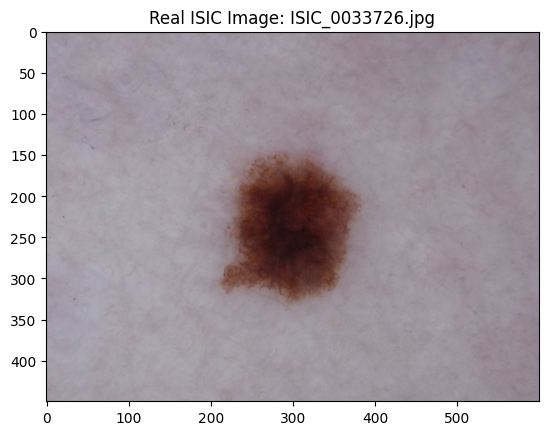

In [11]:
if downloaded > 0:
  sample = os.listdir('data/labeled_real')[0]
  img = Image.open(f'data/labeled_real/{sample}')
  plt.imshow(img)
  plt.title(f"Real ISIC Image: {sample}")
  plt.show()  ##Showing Sample